In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv(dotenv_path='../../.env')

DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "postgres")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "violencia_genero_db")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

print("Conexión exitosa a la base de datos PostgreSQL")

Conexión exitosa a la base de datos PostgreSQL


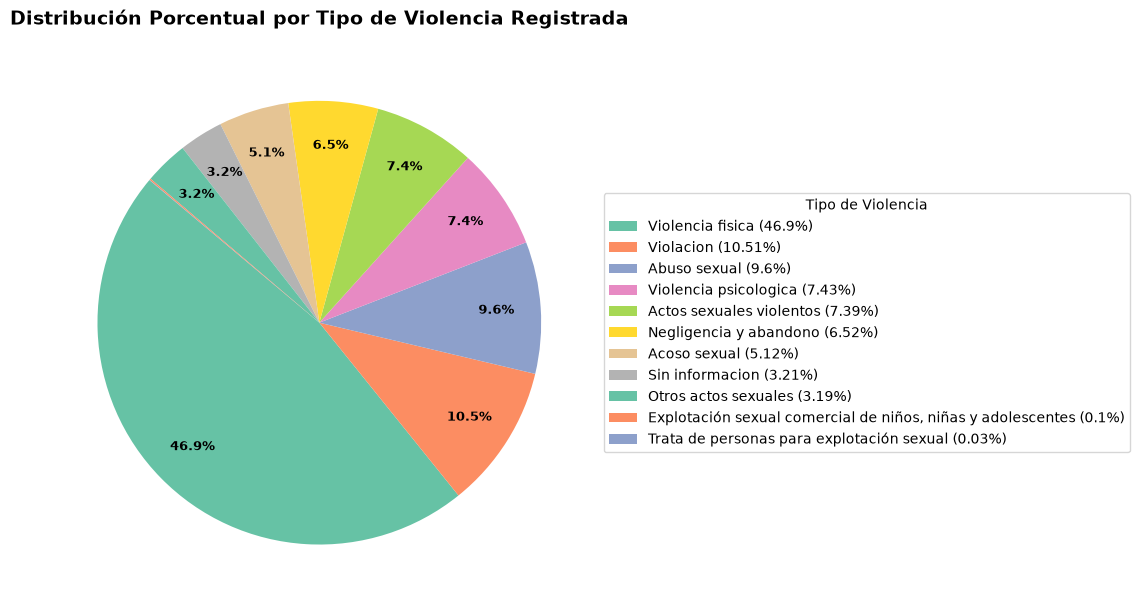

,tipo_violencia,total_casos,porcentaje_total
0,Violencia fisica,3692,46.90
1,Violacion,827,10.51
2,Abuso sexual,756,9.60
3,Violencia psicologica,585,7.43
4,Actos sexuales violentos,582,7.39
5,Negligencia y abandono,513,6.52
6,Acoso sexual,403,5.12
7,Sin informacion,253,3.21
8,Otros actos sexuales,251,3.19
9,"Explotación sexual comercial de niños, niñas y...",8,0.10


In [ ]:
output_dir = '../Graficas/graficas_primera_entrega' if os.path.exists('../Graficas/graficas_primera_entrega') else 'Docs/Graficas/graficas_primera_entrega'
os.makedirs(output_dir, exist_ok=True)

query_kpi = "SELECT * FROM vista_kpi_tipo_violencia ORDER BY total_casos DESC;"
df_kpi = pd.read_sql(query_kpi, engine)

plt.figure(figsize=(10, 7))


def autopct_format(values):
    def my_format(pct):
        return f'{pct:.1f}%' if pct > 1.5 else ''
    return my_format

wedges, texts, autotexts = plt.pie(
    df_kpi['total_casos'], 
    autopct=autopct_format(df_kpi['total_casos']),
    startangle=140, 
    colors=sns.color_palette('Set2', len(df_kpi)),
    pctdistance=0.8,
    textprops={'fontsize': 9, 'color': 'black', 'weight': 'bold'}
)


legend_labels = [f'{row["tipo_violencia"]} ({row["porcentaje_total"]}%)' for _, row in df_kpi.iterrows()]
plt.legend(
    wedges, 
    legend_labels, 
    title="Tipo de Violencia", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1), 
    fontsize=10
)

plt.title('Distribución Porcentual por Tipo de Violencia Registrada', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Guardar y mostrar
plt.savefig(os.path.join(output_dir, '01_distribucion_tipo_violencia_torta.png'), dpi=300, bbox_inches='tight')
plt.show()

df_kpi

Distribución de Violencia: La violencia física representa casi la mitad de los registros (46.9%), seguida por delitos sexuales (20.1% entre violación y abuso).

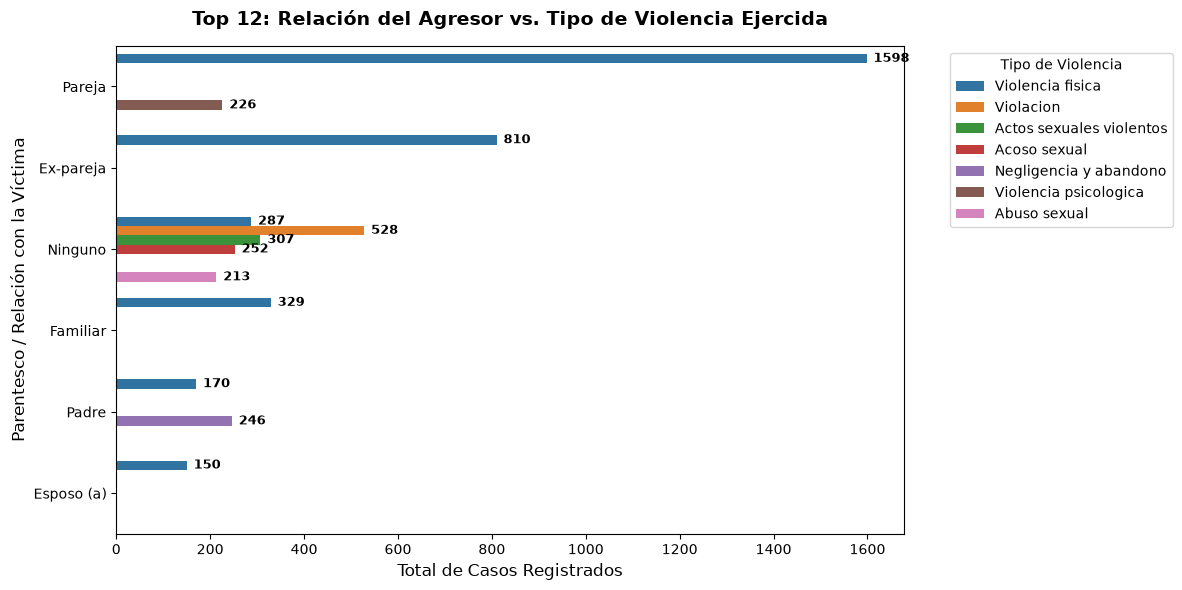

,relacion_agresor,tipo_violencia,total_casos
0,Pareja,Violencia fisica,1598
1,Ex-pareja,Violencia fisica,810
2,Ninguno,Violacion,528
3,Familiar,Violencia fisica,329
4,Ninguno,Actos sexuales violentos,307
5,Ninguno,Violencia fisica,287
6,Ninguno,Acoso sexual,252
7,Padre,Negligencia y abandono,246
8,Pareja,Violencia psicologica,226
9,Ninguno,Abuso sexual,213


In [ ]:
output_dir = '../Graficas/graficas_primera_entrega' if os.path.exists('../Graficas/graficas_primera_entrega') else 'Docs/Graficas/graficas_primera_entrega'
os.makedirs(output_dir, exist_ok=True)

query_agresor = "SELECT * FROM vista_eda_agresor_violencia ORDER BY total_casos DESC LIMIT 12;"
df_agresor = pd.read_sql(query_agresor, engine)

plt.figure(figsize=(12, 6))
bars = sns.barplot(
    data=df_agresor, 
    x='total_casos', 
    y='relacion_agresor', 
    hue='tipo_violencia', 
    palette='tab10'
)


for p in bars.patches:
    width = p.get_width()
    if width > 0: 
        bars.annotate(
            f'{int(width)}',
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center',
            xytext=(5, 0),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

plt.title('Top 12: Relación del Agresor vs. Tipo de Violencia Ejercida', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total de Casos Registrados', fontsize=12)
plt.ylabel('Parentesco / Relación con la Víctima', fontsize=12)
plt.legend(title='Tipo de Violencia', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()


plt.savefig(os.path.join(output_dir, '02_agresor_vs_tipo_violencia.png'), dpi=300, bbox_inches='tight')
plt.show()


df_agresor

Entorno del Agresor: La mayoría de agresiones provienen de personas pertenecientes al círculo cercano o intrafamiliar.

/tmp/ipykernel_34475/2670823072.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=df_ciclo, x='ciclo_vida', y='total_casos', palette='Purples_r')


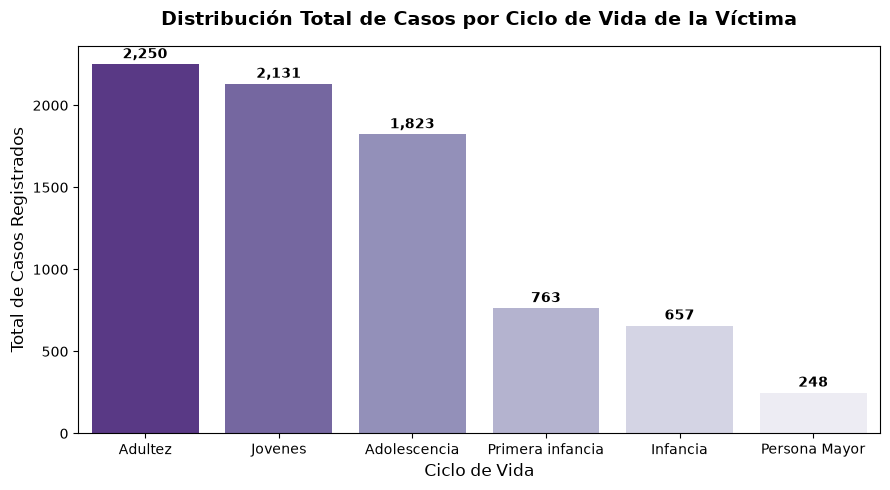

,ciclo_vida,total_casos
1,Adultez,2250
3,Jovenes,2131
0,Adolescencia,1823
5,Primera infancia,763
2,Infancia,657
4,Persona Mayor,248


In [ ]:
output_dir = '../Graficas/graficas_primera_entrega' if os.path.exists('../Graficas/graficas_primera_entrega') else 'Docs/Graficas/graficas_primera_entrega'
os.makedirs(output_dir, exist_ok=True)

query_perfil = "SELECT * FROM vista_eda_perfil_tiempo;"
df_perfil = pd.read_sql(query_perfil, engine)

df_ciclo = df_perfil.groupby('ciclo_vida')['total_casos'].sum().reset_index().sort_values(by='total_casos', ascending=False)

plt.figure(figsize=(9, 5))
bars = sns.barplot(data=df_ciclo, x='ciclo_vida', y='total_casos', palette='Purples_r')

for p in bars.patches:
    bars.annotate(
        f'{int(p.get_height()):,}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 7), 
        textcoords='offset points',
        fontweight='bold',
        fontsize=10
    )

plt.title('Distribución Total de Casos por Ciclo de Vida de la Víctima', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ciclo de Vida', fontsize=12)
plt.ylabel('Total de Casos Registrados', fontsize=12)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, '03_casos_por_ciclo_vida.png'), dpi=300, bbox_inches='tight')
plt.show()

df_ciclo

Ciclo de Vida: Entre la adolescencia y la adultez concentran la mayor cantidad de registros reportados.